<a href="https://colab.research.google.com/github/hectorjimenez12/CC5205_Proyecto/blob/main/Hito3_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 3 Proyecto Mineria de datos

In [1]:
import pandas as pd
import numpy as np
import random
import torch
from torch.utils.data import TensorDataset, DataLoader

seed =  3495 #5937261 #  #123456

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True


In [2]:
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam.csv'
df_general = pd.read_csv(url)
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_description_data.csv.zip'
df_descriptions = pd.read_csv(url)
df_descriptions

,steam_appid,detailed_description,about_the_game,short_description
0,10,Play the world's number 1 online action game. ...,Play the world's number 1 online action game. ...,Play the world's number 1 online action game. ...
1,20,One of the most popular online action games of...,One of the most popular online action games of...,One of the most popular online action games of...
2,30,Enlist in an intense brand of Axis vs. Allied ...,Enlist in an intense brand of Axis vs. Allied ...,Enlist in an intense brand of Axis vs. Allied ...
3,40,Enjoy fast-paced multiplayer gaming with Death...,Enjoy fast-paced multiplayer gaming with Death...,Enjoy fast-paced multiplayer gaming with Death...
4,50,Return to the Black Mesa Research Facility as ...,Return to the Black Mesa Research Facility as ...,Return to the Black Mesa Research Facility as ...
...,...,...,...,...
27329,1065230,"<img src=""https://steamcdn-a.akamaihd.net/stea...","<img src=""https://steamcdn-a.akamaihd.net/stea...",The Room of Pandora is a third-person interact...
27330,1065570,Have you ever been so lonely that no one but y...,Have you ever been so lonely that no one but y...,Cyber Gun is a hardcore first-person shooter w...
27331,1065650,<strong>Super Star Blast </strong>is a space b...,<strong>Super Star Blast </strong>is a space b...,Super Star Blast is a space based game with ch...
27332,1066700,Pursue a snow-white deer through an enchanted ...,Pursue a snow-white deer through an enchanted ...,Pursue a snow-white deer through an enchanted ...


In [3]:
df_general

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27070,1065230,Room of Pandora,2019-04-24,1,SHEN JIAWEI,SHEN JIAWEI,windows,0,Single-player;Steam Achievements,Adventure;Casual;Indie,Adventure;Indie;Casual,7,3,0,0,0,0-20000,2.09
27071,1065570,Cyber Gun,2019-04-23,1,Semyon Maximov,BekkerDev Studio,windows,0,Single-player,Action;Adventure;Indie,Action;Indie;Adventure,0,8,1,0,0,0-20000,1.69
27072,1065650,Super Star Blast,2019-04-24,1,EntwicklerX,EntwicklerX,windows,0,Single-player;Multi-player;Co-op;Shared/Split ...,Action;Casual;Indie,Action;Indie;Casual,24,0,1,0,0,0-20000,3.99
27073,1066700,New Yankee 7: Deer Hunters,2019-04-17,1,Yustas Game Studio,Alawar Entertainment,windows;mac,0,Single-player;Steam Cloud,Adventure;Casual;Indie,Indie;Casual;Adventure,0,2,0,0,0,0-20000,5.19


# 1. Preprocesamiento de los datos

- Eliminacion de puntuaciones en strings

In [4]:
from string import punctuation
from bs4 import BeautifulSoup

def delete_puntuation(string):
  string = string.lower()
  string = ''.join([ i for i in string if i not in punctuation ])
  return string

def delete_html_parts(text):
  soup = BeautifulSoup(text, 'html.parser').get_text()
  return soup

def remove_special(text):
  return ''.join([i for i in text if ord(i) < 128])

def clean_text(text):
  text = delete_html_parts(text)
  text = delete_puntuation(text)
  text = remove_special(text)
  return text.strip()

print(df_descriptions['detailed_description'][357])
print(clean_text(df_descriptions['detailed_description'][357]))

Il-2 1946 includes all of the original IL-2 series content: IL-2 Sturmovik™: Forgotten Battles, Ace Expansion Pack, Pacific Fighters™ and alternate histry campaigns of year 1946. What was years ago began as a one-aircraft study sim is now an astonishing anthology, with a whopping 229 flyable aircraft and over 300 aircraft total!<br><br><strong>The game has been updated to the latest version 4.12.2.</strong> This community made update includes widescreen support with correct FOV, many new planes, maps and scenarios.<br><br>					<ul class="bb_ul"><li><strong>New Aircraft:</strong> 32 new flyable fighters and bombers, and four new AI aircraft!<br>					</li><li><strong>New Maps:</strong> Large new historical maps of the Kiev region; a map of Manchuria focusing on a border region between USSR, China and Japanese-occupied Korea; a large bonus Burma map; and an online Khalkin Gol / Nomonhan map.<br>					</li><li><strong>New Campaigns:</strong> Nine new campaigns with nearly 200 missions add i

In [5]:
idsRemove = np.where(~ df_descriptions.steam_appid.isin( list(df_general.appid) ))
df_desc =  df_descriptions.drop( labels = np.reshape(idsRemove, -1) , axis = 0).reset_index(level= 0,drop=True)

print(all(df_desc.steam_appid.values == df_general.appid.values))
df_desc.steam_appid.compare(df_general.appid,align_axis=0)

True


Series([], dtype: float64)

In [6]:
text_clean = []
for i,appid in enumerate(df_general.appid):
    #print(i)
    text_clean.append(clean_text(df_desc['detailed_description'][i]))
df_general['description'] = text_clean

<ipython-input-4-2e3e0b7a9584>:10: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, 'html.parser').get_text()
<ipython-input-4-2e3e0b7a9584>:10: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, 'html.parser').get_text()
<ipython-input-4-2e3e0b7a9584>:10: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, 'html.parser').get_text()


- Labels

In [9]:
data = df_general.copy()
data['text_clean'] = data['description']

('[0.7-1.0]', 'Alto')


<Axes: >

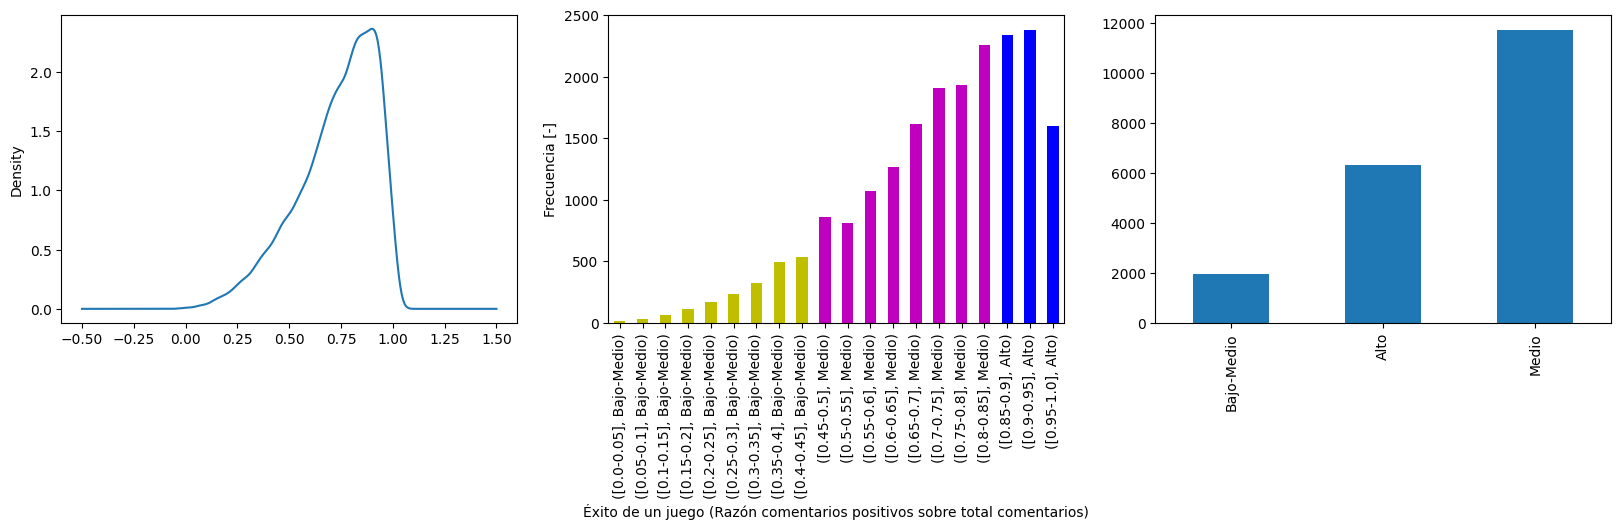

In [10]:
import matplotlib.pyplot as plt
data['total_comment'] = [i + j for i,j in zip(data['positive_ratings'],data['negative_ratings']) ]
data['total_comment'].value_counts().sort_values()
data['pos_r/tot_r'] = np.array(data['positive_ratings'])/(np.array(data['positive_ratings'])+np.array(data['negative_ratings']))

def tag_value(value,ranges,labels):
  for i,val_range in enumerate(ranges):
    if value >= val_range and value <= ranges[i+1]:
      return '[' + str(val_range) + '-' + str(ranges[i+1])+']', labels[i]
print(tag_value(0.8, np.round(np.linspace(0,1,4),1), labels= ['Bajo-Medio']*2 + ['Alto']))

data = data[ data['total_comment'] > 10].reset_index(drop=True)

ranges, labels = np.round(np.linspace(0,1,21),2), ['Bajo-Medio']*9 + ['Medio']*8 + ['Alto']*20
data['posR_interval'] = [tag_value(i,ranges,labels)[0] for i in data['pos_r/tot_r'] ]
data['posR_label']    = [tag_value(i,ranges,labels)[1] for i in data['pos_r/tot_r'] ]

colors = ['b', 'y', 'm', 'c', 'g', 'b', 'r', 'k']
d_color = { k:colors[i] for i,k in enumerate( np.unique(data['posR_label'])  ) }
fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(20,4))
#plt.suptitle('Distribución de razon de comentarios positivos sobre negativos')
data['pos_r/tot_r'].plot(kind='density',ax = ax1)
count_labels = data.loc[ :, ['posR_interval','posR_label'] ].groupby(by ='posR_interval' ).value_counts()
count_labels.plot(kind='bar',color= [d_color[i[1]] for i in count_labels.index] ,ax = ax2)
ax2.set_ylabel('Frecuencia [-]');ax2.set_xlabel('Éxito de un juego (Razón comentarios positivos sobre total comentarios)')
data['posR_label'].value_counts().sort_values().plot(kind='bar',ax = ax3)

In [11]:
idsRemove = np.where( data.posR_label.isin( ['Medio'] ))
data = data.drop( labels = np.reshape(idsRemove, -1) , axis = 0).reset_index(level= 0,drop=True)
data['label'] = data['posR_label']

- Hacer conteo de palabras

In [12]:
from collections import Counter
all_strings = ' '.join(list(data['text_clean']))
print(all_strings[0:200])
print(data['text_clean'][0:2])

play the worlds number 1 online action game engage in an incredibly realistic brand of terrorist warfare in this wildly popular teambased game ally with teammates to complete strategic missions take o
0    play the worlds number 1 online action game en...
1    enlist in an intense brand of axis vs allied t...
Name: text_clean, dtype: object


In [13]:
freq_words = Counter(all_strings.split()) #cerca de 9000 palabras unicas
sort_word = sorted(freq_words,key=freq_words.get, reverse = True )
word_index = { word:index for index,word in enumerate(sort_word,1) }

#convertir a vector numerico cada mensaje
num_mail = []
for i in data['text_clean']:
  num_mail.append([ word_index[k] for k in i.split() ])

In [15]:
print(list(word_index.items())[0:10])
print(num_mail[100])
print(data['text_clean'][100])

[('the', 1), ('and', 2), ('to', 3), ('of', 4), ('a', 5), ('you', 6), ('in', 7), ('your', 8), ('with', 9), ('is', 10)]
[6, 20, 7, 126, 4, 5435, 21, 2501, 3666, 22, 1, 272, 4836, 3, 114, 1, 8991, 408, 3833, 76, 614, 386, 18526, 249, 734, 141, 7139, 10, 85, 1, 898, 6, 138, 175, 484, 5, 1073, 4, 23124, 1003, 192, 43, 5571, 13, 53, 1433, 1, 6445, 1603, 2927, 2513, 1, 1044, 9, 2842, 2436, 909, 3115, 2, 90, 1186, 7, 1, 1482, 3, 3968, 1451, 555, 89, 18, 107, 2596, 742, 2, 8117, 408, 1584, 1387, 619, 1487, 255, 16, 524, 5435, 2174, 3, 6058, 408, 134, 37, 25, 10839, 798, 6, 5, 260, 1710, 3, 2784, 1, 555, 2, 2448, 4, 1, 408, 886, 247, 6, 29, 8992, 742, 1107, 14, 1, 7139, 3719, 89, 2, 5895, 133, 23, 257, 3, 8117, 89, 4, 3721, 8093, 777, 5, 245, 3, 168, 1, 419, 6, 138, 61, 94, 3397, 1625, 13, 6, 124, 1, 174, 408, 493, 32, 133, 87, 119, 3, 541, 1, 28, 1758, 1214, 4836, 193, 23, 1429, 42, 310, 33096, 9, 1, 1044, 2, 175, 1173, 3, 4132, 5435, 6251]
you are in control of xcom an organization formed by t

- Padding de los vectores.

La Figura permite analizar las longitudes de cada reseña.

(0.0, 10000.0)

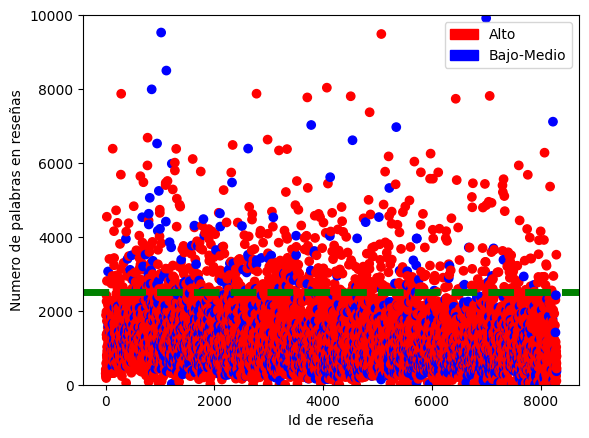

In [23]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

legend_elements = [#Line2D([0], [0], marker='o', color='w', label='Scatter',markerfacecolor='g', markersize=15),
                   Patch(facecolor='red', edgecolor='red', label='Alto'),
                   Patch(facecolor='blue', edgecolor='blue', label='Bajo-Medio')]

colord = {'Bajo-Medio':'blue','Alto':'red'}
plt.scatter(x = data.index ,y = [len(i) for i in data['text_clean']], c = data['label'].map(colord))
plt.axhline(y = 2500, color = 'green', linestyle = '--',linewidth=5)
plt.ylabel('Numero de palabras en reseñas')
plt.xlabel('Id de reseña')
plt.legend(handles = legend_elements)
plt.ylim([min([len(i) for i in data['text_clean']]),10000 ])

Las longitudes estan en un rango aproximado entre 1 y 800, siendo 200 un una cota superior que permite contener a la mayor cantidad de mails. Esto lleva a seleccionar 200 como el largo maximo de un mail. De esta manera, los vectores numericos de los mails que tengan una longitud menor a 200 seran rellenados con 0 al inicio del vector de tal manera de obtener una longitud 200. En cambio, los vectores numericos de longitud mayor a 200 seran cortados en la posicion 200.

SEPARAR LAS RESEÑAS SEGUN UN LARGO MAXIMO DE 200 O DOS PUNTOS DE SEPARACION

In [17]:
data['label_num'] = pd.get_dummies( data["posR_label"]  )['Alto']

In [18]:
#eliminacion de datos con 0 palabras
idx_nonzero_len = [ idx for idx,mail in enumerate(num_mail) if len(mail) > 0 ]
X_num_mail = [num_mail[i] for i in idx_nonzero_len]
Y_num_label = [data['label_num'][i] for i in idx_nonzero_len]

In [19]:
#funcion para hacer padding en los datos
def pad_features(words_embedding, seq_length):
  features = np.zeros((len(words_embedding), seq_length), dtype=int)
  for i, row in enumerate(words_embedding):
    features[i, -len(row):] = np.array(row)[:seq_length] # -len(row): from -len(row) to postion 200. the rest is zero
  return features

In [24]:
max_lenght = 2500
features = pad_features(words_embedding = X_num_mail, seq_length = max_lenght)

- Particion de datos en train val y test de manera estratificada

In [ ]:
#unique_y = np.unique(Y_num_label)
#id_train, id_val, id_test = [],[],[]

#for i, label in enumerate(unique_y):
#  id_data =  [k for k in range(len(Y_num_label)) if Y_num_label[k] == label ] #list(range(features.shape[0]))
#  random.shuffle(id_data)
#  id_train += id_data[0:int(len(id_data)*0.7)]
#  id_val   += id_data[int(len(id_data)*0.7):int(len(id_data)*0.8)]
#  id_test  += id_data[int(len(id_data)*0.8):int(len(id_data)+1)]

#X_train, X_val, X_test = features[id_train ,:],features[id_val ,:],features[id_test ,:]
#Y_train, Y_val, Y_test = np.array(Y_num_label)[id_train],np.array(Y_num_label)[id_val],np.array(Y_num_label)[id_test]


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(features, np.array(Y_num_label), test_size=0.2,stratify= Y_num_label , random_state=seed)
X_train, X_val , Y_train, Y_val  = train_test_split(X_train, Y_train, test_size=10/80, stratify= Y_train, random_state=seed)

- Datasets y dataloaders

In [26]:

# crear Tensor datasets
train_data = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
valid_data = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(Y_val))
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(Y_test))
# dataloaders
batch_size = 50

train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size, drop_last=True)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=batch_size, drop_last=True)
test_loader = DataLoader(test_data, shuffle=False, batch_size=batch_size, drop_last=True)

In [27]:
# Chequear si tenemos GPU
train_on_gpu=torch.cuda.is_available()

if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

Training on GPU.


In [28]:
def accuracy(y_pred,y_real):
  running_corrects = torch.sum(torch.Tensor(y_pred) == torch.Tensor(y_real))
  return float(running_corrects/len(y_pred))

accuracy([1,2,3,7,8],[1,2,5,7,8])

0.800000011920929

# 1 Resolucion del problema

- RED NEURONAL

In [29]:
import torch.nn as nn

class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, output_size, embedding_dim, hidden_dim, n_layers, drop_prob=0.5):

        super(SentimentRNN, self).__init__()

        self.output_size = output_size
        self.n_layers = n_layers
        self.hidden_dim = hidden_dim

        # Capas embedding y LSTM
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers,
                            dropout=drop_prob, batch_first=True)

        # dropout
        self.dropout = nn.Dropout(drop_prob)

        # Capa lineal y sigmoide
        self.fc = nn.Linear(hidden_dim, output_size)
        self.sig = nn.Sigmoid()

    def forward(self, x, hidden):

        embeds = self.embedding(x)
        lstm_out, hidden = self.lstm(embeds, hidden)

        #Tomamos solo el último valor de salida del LSTM
        lstm_out = lstm_out[:,-1,:]

        # dropout y fully-connected
        out = self.dropout(lstm_out)
        out = self.fc(out)

        # sigmoide
        sig_out = self.sig(out)

        # retornar sigmoide y último estado oculto
        return sig_out, hidden


    def init_hidden(self, batch_size):
        # Crea dos nuevos tensores con tamaño n_layers x batch_size x hidden_dim,
        # inicializados a cero, para estado oculto y memoria de LSTM
        weight = next(self.parameters()).data

        if(train_on_gpu):
          hidden = (weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().cuda(),
                   weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().cuda())
        else:
          hidden = (weight.new(self.n_layers, batch_size, self.hidden_dim).zero_(),
                   weight.new(self.n_layers, batch_size, self.hidden_dim).zero_())

        return hidden

In [30]:
# Instanciamos la red
vocab_size = len(word_index) + 1 # +1 for zero padding + our word tokens
output_size = 1
embedding_dim = 400
hidden_dim = 256
n_layers = 2
net = SentimentRNN(vocab_size, output_size, embedding_dim, hidden_dim, n_layers)
print(net)

SentimentRNN(
  (embedding): Embedding(103179, 400)
  (lstm): LSTM(400, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sig): Sigmoid()
)


In [31]:
# loss and optimization functions
lr=0.001
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

In [32]:
# training params
epochs = 5
counter = 0
print_every = 100
clip=5 # gradient clipping

# Enviar red al GPU
if(train_on_gpu):
    net.cuda()

net.train()
# Bucle de entrenamiento
for e in range(epochs):
    # Inicializar estado oculto
    h = net.init_hidden(batch_size) # deberia tener dim (nlayers, batch size , hidden dim)

    # Bucle para batchs
    for inputs, labels in train_loader: #input deberia tener dim (batch size x len seq)
        counter += 1

        if(train_on_gpu):
            inputs, labels = inputs.cuda(), labels.cuda()

        # Crear nuevas variables para estados ocultos, sino se haría
        # backprop para todos los pasos del bucle
        h = tuple([each.data for each in h])

        net.zero_grad()

        # Hacer pasada forward
        output, h = net(inputs, h)

        # Calcular loss y hacer backprop
        loss = criterion(output.squeeze(), labels.float())
        loss.backward()
        # gradient clipping
        nn.utils.clip_grad_norm_(net.parameters(), clip)
        optimizer.step()

        # Mensajes
        if counter % print_every == 0:
            # Validation loss
            val_h = net.init_hidden(batch_size)
            val_losses = []
            net.eval()
            y_pred, y_real = [], []

            for inputs, labels in valid_loader:

                val_h = tuple([each.data for each in val_h])

                if(train_on_gpu):
                    inputs, labels = inputs.cuda(), labels.cuda()

                output, val_h = net(inputs, val_h)
                val_loss = criterion(output.squeeze(), labels.float())
                val_losses.append(val_loss.item())

                y_pred +=  (output > 0.5 ).squeeze().float().tolist()
                y_real +=  labels.float().tolist()

            acc_val = accuracy(y_pred,y_real)
            net.train()
            print("Época: {}/{}...".format(e+1, epochs),
                  "Paso: {}...".format(counter),
                  "Loss: {:.6f}...".format(loss.item()),
                  "Val Loss: {:.6f}".format(np.mean(val_losses)),
                  "Accuracy Val: {:.6f}".format(acc_val) )

Época: 1/5... Paso: 100... Loss: 0.531645... Val Loss: 0.541646 Accuracy Val: 0.760000
Época: 2/5... Paso: 200... Loss: 0.540421... Val Loss: 0.525130 Accuracy Val: 0.776250
Época: 3/5... Paso: 300... Loss: 0.334685... Val Loss: 0.654691 Accuracy Val: 0.745000
Época: 4/5... Paso: 400... Loss: 0.147217... Val Loss: 0.801897 Accuracy Val: 0.756250
Época: 5/5... Paso: 500... Loss: 0.035931... Val Loss: 1.110798 Accuracy Val: 0.743750


Evaluacion en test

In [33]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

net.eval()
y_pred, y_real = [], []
for inputs, labels in test_loader:
  val_h = tuple([each.data for each in val_h])
  if(train_on_gpu):
    inputs, labels = inputs.cuda(), labels.cuda()
    output, val_h = net(inputs, val_h)

  y_pred +=  (output > 0.5 ).squeeze().float().tolist()
  y_real +=  labels.float().tolist()

acc_test = accuracy(y_pred,y_real)
print(acc_test)
confusion_matrix(y_real, y_pred)
classification_report(y_real,y_pred,output_dict=True)


0.739393949508667


{'0.0': {'precision': 0.4364820846905538,
  'recall': 0.34271099744245526,
  'f1-score': 0.3839541547277937,
  'support': 391},
 '1.0': {'precision': 0.8086373790022338,
  'recall': 0.8625893566322478,
  'f1-score': 0.8347425057647962,
  'support': 1259},
 'accuracy': 0.7393939393939394,
 'macro avg': {'precision': 0.6225597318463938,
  'recall': 0.6026501770373516,
  'f1-score': 0.609348330246295,
  'support': 1650},
 'weighted avg': {'precision': 0.7204478516835265,
  'recall': 0.7393939393939394,
  'f1-score': 0.7279193268220884,
  'support': 1650}}

**Analisis de resultados:**
En esta tarea se evalua el rendimiento y capacidad del modelo con el dataset de test. La evaluacion se lleva a cabo considerando promedios de metricas **NO** ponderados según cantidad de datos por clase. Las metricas analizadas son precision, recall y f1-score. El modelo obtiene un rendimiento alto debido a que tiene metricas promedio de 0.97, 0.92 y 0.94 en precision, recall y f1-score, respectivamente. El modelo obtiene metricas superiores a 0.97 para la clase '0' (correo ham), mientras que valores superiores a 0.84 para la clase '1'(spam). Es decir, el modelo no esta predicciendo correctamente la clase spam debido a falsos negativos (recall). Esto ocurre cuando el modelo predice que un correo es 'ham' cuando en realidad es 'spam'. Este problema se puede deber a multiples condiciones:

- Los datos estan desbalanceados, ya que hay una cantidad mucho mayor de correos tipo 'ham' que 'spam'. Esto puede afectar el proceso de entrenamiento, ya que la red intentará minimizar los errores de todos los datos, dando lugar a correcciones mas significativas para la clase mayoritaria (ham). Por lo tanto, la red se centrará más en reducir los errores los errores de prediccion de correos tipo 'ham', ya que estos tendrán un impacto más notable en las metricas de rendimiento.




# 2 Experimento de oversampling con LSTM

Una posible solucion al problema de desbalance es utilizar tecnicas de oversampling. Esta tecnica consiste en seleccionar aleatoriamente datos de la **clase minoritaria en el conjunto de datos de entrenamiento** hasta igualar el numero de datos de todas las clases presenten en el dataset de entrenamiento. A modo de experimentacion se decide probar esta tecnica con el objetivo de evaluar si la red neuronal mejora su rendimiento sobre la clase 'spam'.

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(features, np.array(Y_num_label), test_size=0.2,stratify= Y_num_label , random_state=seed)
X_train, X_val , Y_train, Y_val  = train_test_split(X_train, Y_train, test_size=10/80, stratify= Y_train, random_state=seed)

In [35]:
Y_train = pd.DataFrame(Y_train)
counts = np.unique(Y_train, return_counts = True)
id_oversampling = random.choices( list(Y_train[Y_train[0].isin([1])].index) ,k = max(counts[1]) - min(counts[1]) )
Y_train = list(Y_train[0]) + [1]*(max(counts[1]) - min(counts[1]))
X_train = np.concatenate( (X_train, X_train[ id_oversampling ,:]), axis = 0)

- Datasets y dataloaders

In [36]:
import torch
from torch.utils.data import TensorDataset, DataLoader
# crear Tensor datasets
train_data = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(np.array(Y_train)))
valid_data = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(Y_val))
test_data = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(Y_test))
# dataloaders
batch_size = 50
train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size, drop_last=True)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=batch_size, drop_last=True)
test_loader = DataLoader(test_data, shuffle=False, batch_size=batch_size, drop_last=True)

In [37]:
# Chequear si tenemos GPU
train_on_gpu=torch.cuda.is_available()
if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

Training on GPU.


In [38]:
net = SentimentRNN(vocab_size, output_size, embedding_dim, hidden_dim, n_layers)
print(net)
# loss and optimization functions
lr=0.001
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

SentimentRNN(
  (embedding): Embedding(103179, 400)
  (lstm): LSTM(400, 256, num_layers=2, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sig): Sigmoid()
)


In [39]:
# training params
epochs = 10
counter = 0
print_every = 100
clip=5 # gradient clipping
# Enviar red al GPU
if(train_on_gpu):
    net.cuda()
net.train()
# Bucle de entrenamiento
for e in range(epochs):
    # Inicializar estado oculto
    h = net.init_hidden(batch_size) # deberia tener dim (nlayers, batch size , hidden dim)
    # Bucle para batchs
    for inputs, labels in train_loader: #input deberia tener dim (batch size x len seq)
        counter += 1
        if(train_on_gpu):
            inputs, labels = inputs.cuda(), labels.cuda()
        # Crear nuevas variables para estados ocultos, sino se haría
        # backprop para todos los pasos del bucle
        h = tuple([each.data for each in h])
        net.zero_grad()
        # Hacer pasada forward
        output, h = net(inputs, h)
        # Calcular loss y hacer backprop
        loss = criterion(output.squeeze(), labels.float())
        loss.backward()
        # gradient clipping
        nn.utils.clip_grad_norm_(net.parameters(), clip)
        optimizer.step()
        # Mensajes
        if counter % print_every == 0:
            # Validation loss
            val_h = net.init_hidden(batch_size)
            val_losses = []
            net.eval()
            y_pred, y_real = [], []
            for inputs, labels in valid_loader:
                val_h = tuple([each.data for each in val_h])
                if(train_on_gpu):
                    inputs, labels = inputs.cuda(), labels.cuda()
                output, val_h = net(inputs, val_h)
                val_loss = criterion(output.squeeze(), labels.float())
                val_losses.append(val_loss.item())
                y_pred +=  (output > 0.5 ).squeeze().float().tolist()
                y_real +=  labels.float().tolist()
            acc_val = accuracy(y_pred,y_real)
            net.train()
            print("Época: {}/{}...".format(e+1, epochs),
                  "Paso: {}...".format(counter),
                  "Loss: {:.6f}...".format(loss.item()),
                  "Val Loss: {:.6f}".format(np.mean(val_losses)),
                  "Accuracy Val: {:.6f}".format(acc_val) )

Época: 1/10... Paso: 100... Loss: 0.458683... Val Loss: 0.541902 Accuracy Val: 0.763750
Época: 2/10... Paso: 200... Loss: 0.304172... Val Loss: 0.586615 Accuracy Val: 0.773750
Época: 2/10... Paso: 300... Loss: 0.300839... Val Loss: 0.572742 Accuracy Val: 0.756250
Época: 3/10... Paso: 400... Loss: 0.091720... Val Loss: 0.730888 Accuracy Val: 0.758750
Época: 3/10... Paso: 500... Loss: 0.197170... Val Loss: 0.643839 Accuracy Val: 0.753750
Época: 4/10... Paso: 600... Loss: 0.011272... Val Loss: 0.959965 Accuracy Val: 0.717500
Época: 4/10... Paso: 700... Loss: 0.026554... Val Loss: 1.015390 Accuracy Val: 0.713750
Época: 5/10... Paso: 800... Loss: 0.025410... Val Loss: 1.179845 Accuracy Val: 0.748750
Época: 6/10... Paso: 900... Loss: 0.009172... Val Loss: 1.372216 Accuracy Val: 0.688750


KeyboardInterrupt: ignored

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
net.eval()
y_pred, y_real = [], []
for inputs, labels in test_loader:
  val_h = tuple([each.data for each in val_h])
  if(train_on_gpu):
    inputs, labels = inputs.cuda(), labels.cuda()
    output, val_h = net(inputs, val_h)
  y_pred +=  (output > 0.5 ).squeeze().float().tolist()
  y_real +=  labels.float().tolist()
acc_test = accuracy(y_pred,y_real)
print(acc_test)
confusion_matrix(y_real, y_pred)
classification_report(y_real,y_pred,output_dict=True)

0.9809523820877075


{'0.0': {'precision': 0.9825708061002179,
  'recall': 0.9955849889624724,
  'f1-score': 0.9890350877192983,
  'support': 906},
 '1.0': {'precision': 0.9696969696969697,
  'recall': 0.8888888888888888,
  'f1-score': 0.927536231884058,
  'support': 144},
 'accuracy': 0.9809523809523809,
 'macro avg': {'precision': 0.9761338878985938,
  'recall': 0.9422369389256806,
  'f1-score': 0.9582856598016781,
  'support': 1050},
 'weighted avg': {'precision': 0.9808052513934867,
  'recall': 0.9809523809523809,
  'f1-score': 0.9806009589190368,
  'support': 1050}}

La tecnica de oversampling permite mejorar levemente el rendimiento de la red neuronal recurrente sin incurrir en overfitting. El modelo con oversampling obtiene valores promedio sin ponderación de 0.98, 0.94 y 0.96 para las metricas precision, recall y f1-score, respectivamente. Es decir, mejora en 0.2 en la metrica recall con respecto al modelo entrenado sin oversampling. Esta mejora se da sobre la prediccion de la clase 'spam'. Por lo tanto, la tecnica oversampling puede ser adecuada si se quiere reducir los errores de prediccion sobre la clase minoritaria de un problema de clasificación.

# Conclusiones:

- La red neuronal recurrente LSTM genera predicciones de manera acertada para la clasificacion de tipos de correos ham vs spam. Todos los modelos entrenados obtienen valores promedios superiores a 0.92 en precision, recall y f1-score. Este tipo de modelos funciona correctamente sobre trabajos asociados a palabras debido a que considera las relaciones entre palabras y permite identificar la estructura de correos de tipo spam en base al contexto extraido de las palabras.

- La red neuronal recurrente LSTM es un modelo de aprendizaje profundo que extrae las caracteristicas de los datos utilizando embeddings. Esta tecnica funciona de manera acertada debido a que se tiene un dataset con un gran numero de datos. Esto permite a la red entrenarse de manera de obtener una caracterizacion de las palabras para este problema en especifico.